# Test importing image into eWaterCycle


In [26]:
from grpc4bmi.bmi_client_singularity import BmiClientSingularity

model = BmiClientSingularity('/home/avandervee3/leaky_empty.sif', work_dir='/tmp')
print(model.get_component_name())
del model

leakybucket_bmi_modified


In [27]:
from ewatercycle_leakybucket.model import LeakyBucket
from ewatercycle.base.forcing import GenericLumpedForcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
import ewatercycle.models
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ewatercycle.container import ContainerImage

#shapefile that describes the basin we want to study.
shapeFile = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/AralSeaBasin.shp"

#GRDC station ID for the observation station
grdc_station_id = "2617110"  # GRDC station ID
basin_name = "AMU DARYA"

#period of interest. Make sure that ERA5 is available on your machine for this period.
experiment_start_time="1990-01-01T00:00:00Z"
experiment_end_time="1990-12-31T00:00:00Z"

In [64]:
forcing = GenericLumpedForcing.generate(
    dataset='ERA5',
    start_time=experiment_start_time,
    end_time=experiment_end_time,
    shape=shapeFile
)

In [29]:
my_image = ContainerImage("/home/avandervee3/leaky_empty.sif")

model = LeakyBucket(forcing=forcing,
                    bmi_image=my_image)
cfg_file, _ = model.setup(leakiness=0.10)


model.initialize(cfg_file)


In [30]:


import xarray as xr

discharges = []
storages = []
n=0;
while model.time < model.end_time:
    discharges.append(model.get_value_as_xarray("discharge"))
    storages.append(model.get_value_as_xarray("storage"))
    model.update()
    # if n % 100 == 0:
    #     #model.reset_storage()  # reset storage to 30 mm every 100 time steps
    # n+=1





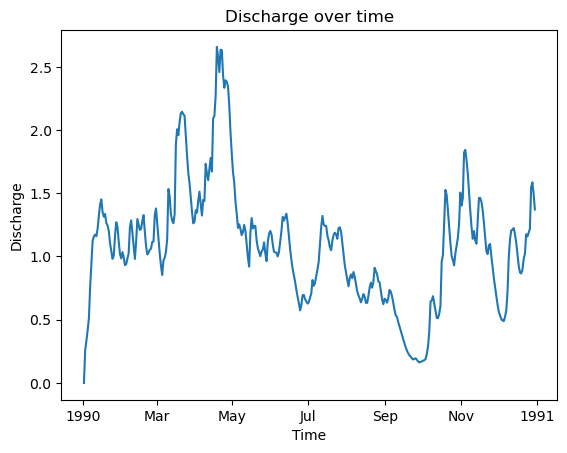

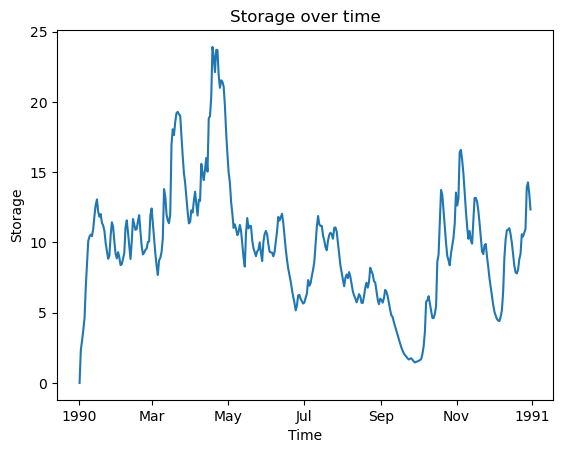

In [31]:
# Combine the time series
discharge = xr.concat(discharges, dim="time")
storages = xr.concat(storages, dim="time")

# Plot discharge on its own figure
plt.figure()            # creates a new figure
discharge.plot()
plt.title("Discharge over time")
plt.xlabel("Time")
plt.ylabel("Discharge")  # or your units
plt.show()

# Plot storage on its own figure
plt.figure()            # creates another new figure
storages.plot()
plt.title("Storage over time")
plt.xlabel("Time")
plt.ylabel("Storage")  # or your units
plt.show()

In [32]:
ewatercycle.models

<module 'ewatercycle.models' from '/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/ewatercycle/models.py'>

In [33]:
print(ewatercycle.models.sources)

ModelSources[
    "HBV",
    "HBVLocal",
    "Hype",
    "LeakyBucket",
    "Lisflood",
    "MarrmotM01",
    "MarrmotM14",
    "PCRGlobWB",
    "Wflow",
    "WflowJl"
]


In [34]:
import sys
from pathlib import Path

# Add the parent directory of Package3_ActualModel to sys.path
sys.path.append(str(Path("/home/avandervee3").resolve()))

from ewatercycle.base.model import LocalModel
from ewatercycle_leakybucket.model import LeakyBucketMethods
from typing import Type
from Package3_ActualModel.leakybucket_bmi_modified import LeakyBucketBmi_reset_storage  # your modified BMI

class LocalModelCustomBucket(LocalModel, LeakyBucketMethods):
    """Local eWaterCycle model using the modified CustomBucket BMI."""
    bmi_class: Type = LeakyBucketBmi_reset_storage


In [46]:
model_custom = LocalModelCustomBucket(forcing=forcing)
cfg_file, _ = model_custom.setup(leakiness=0.10)


model_custom.initialize(cfg_file)

In [ ]:


import xarray as xr

discharges = []
storages = []
n=0;
while model_custom.time < model_custom.end_time:
    discharges.append(model_custom.get_value_as_xarray("discharge"))
    storages.append(model_custom.get_value_as_xarray("storage"))
    model_custom.update()
    if n % 100 == 0:
        model_custom.reset_storage()  # reset storage to 30 mm every 100 time steps
    n+=1





AttributeError: 'LocalModelCustomBucket' object has no attribute 'reset_storage'

In [45]:
# Combine the time series
discharge = xr.concat(discharges, dim="time")
storages = xr.concat(storages, dim="time")

# Plot discharge on its own figure
plt.figure()            # creates a new figure
discharge.plot()
plt.title("Discharge over time")
plt.xlabel("Time")
plt.ylabel("Discharge")  # or your units
plt.show()

# Plot storage on its own figure
plt.figure()            # creates another new figure
storages.plot()
plt.title("Storage over time")
plt.xlabel("Time")
plt.ylabel("Storage")  # or your units
plt.show()

TypeError: No numeric data to plot.

<Figure size 640x480 with 0 Axes>

In [57]:
import sys
from pathlib import Path

sys.path.append(str(Path("/home/avandervee3/ewatercycle-MyCustomReset").resolve()))
#bmi_image: ContainerImage = ContainerImage("modified_leaky.sif")
from ewatercycle.base.forcing import GenericLumpedForcing
from ewatercycle_MyCustomReset.model import CustomBucket




In [59]:
# model_CB = CustomBucket(forcing=forcing)
# cfg_file, _ = model_CB.setup(leakiness=0.10)


# model_CB.initialize(cfg_file)

model_CB = CustomBucket(forcing=forcing)

# Write the config file inside _cfg_dir
cfg_file, _ = model_CB.setup(leakiness=0.10)

# Initialize the containerized model (starts the container)
model_CB.initialize()  # ✅ no arguments here

TimeoutError: Couldn't spawn container within allocated time limit (300 seconds). You may try pulling the docker image with `apptainer build modified_leaky.sif docker://modified:leaky` and then try again.

In [ ]:


import xarray as xr

discharges = []
storages = []
n=0;
while model_custom.time < model_custom.end_time:
    discharges.append(model_custom.get_value_as_xarray("discharge"))
    storages.append(model_custom.get_value_as_xarray("storage"))
    model_custom.update()
    if n % 100 == 0:
        model_custom.reset_storage()  # reset storage to 30 mm every 100 time steps
    n+=1





In [60]:
print(ewatercycle.models.sources)

ModelSources[
    "HBV",
    "HBVLocal",
    "Hype",
    "LeakyBucket",
    "Lisflood",
    "MarrmotM01",
    "MarrmotM14",
    "PCRGlobWB",
    "Wflow",
    "WflowJl"
]


In [ ]:
from ewatercycle.base.forcing import GenericLumpedForcing
from ewatercycle_MyCustomReset.model2 import CustomBucket, LocalModelCustomBucket

# --- Local Python model ---
model_local = LocalModelCustomBucket(forcing=forcing)
print("step1")
model_local.setup(leakiness=0.1)
print("step2")
model_local.initialize()
print("Starting local model run with reset_storage every 100 steps...")
for n in range(500):
    model_local.update()
    if n % 100 == 0:
        model_local.reset_storage()  # ✅ works on local BMI
print("Local model run complete.")
model_local.finalize()



# --- Containerized model ---
model_container = CustomBucket(forcing=forcing)
print("step1")
model_container.setup(leakiness=0.1)
print("step2")
model_container.initialize()

print("Starting containerized model run with reset_storage every 100 steps...")
for n in range(500):
    model_container.update()
    if n % 100 == 0:
        model_container.reset_storage()  # ✅ works inside container
print("Containerized model run complete.")
model_container.finalize()



# --- Local Python model ---
model_local = LocalModelCustomBucket(forcing=forcing)
model_local.setup(leakiness=0.1)
model_local.initialize()

for n in range(500):
    model_local.update()
    if n % 100 == 0:
        model_local.reset_storage()  # ✅ works on local BMI

model_local.finalize()

step1


KeyboardInterrupt: 